# Importing Libraries and Dependencies

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Step 1: Data Acquisition & EDA 

In [2]:
# Read raw data from csv file

cc_df = pd.read_csv('credit_card_dataset.csv')

In [3]:
# Read the first 5 rows of the dataset
cc_df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [4]:
# Check the structure of the dataframe
cc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [5]:
# Statistical summary of the dataframe
cc_df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [6]:
# Just curious to see who made the highest one off purchase!
cc_df[cc_df["ONEOFF_PURCHASES"] == 40761.250000]

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
550,C10574,11547.52001,1.0,49039.57,40761.25,8278.32,558.166886,1.0,1.0,0.916667,0.083333,1,101,22500.0,46930.59824,2974.069421,0.25,12


In [7]:
# Just curious to see who made the highest cash advance!
cc_df[cc_df['CASH_ADVANCE'] == 47137.211760000006]

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE


# Step 2: Data Preprocessing

In [8]:
# Checking if there are any null values present in the dataset
cc_df.isnull().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

* We found that : Two columns have null values. ('MINIMUM_PAYMENTS' and 'CREDIT_LIMIT')
* To fill up those missing values : we will use the median of the respective columns to fill up those missing values.
* Why not replacing missing values with mean ? : The mean can distort the distribution of a feature if it has extreme outliers, which is common in financial data. 

In [9]:

cc_df.loc[(cc_df['MINIMUM_PAYMENTS'].isnull() == True), 'MINIMUM_PAYMENTS'] = cc_df['MINIMUM_PAYMENTS'].median()
cc_df.loc[(cc_df['CREDIT_LIMIT'].isnull() == True), 'CREDIT_LIMIT'] = cc_df['CREDIT_LIMIT'].median()

In [10]:
# Checking null values again.
cc_df.isnull().sum()

CUST_ID                             0
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

In [11]:
# Checking duplicated entries.
cc_df.duplicated().sum()

np.int64(0)

In [12]:
# Droping "Customer ID" column since we wont use it for further analysis.
cc_df.drop("CUST_ID", axis = 1, inplace = True)

In [13]:
cc_df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


# Step 3: Data exploration

In [14]:
# All the columns present in the dataset.
cc_df.columns

Index(['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
       'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
       'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT',
       'TENURE'],
      dtype='object')

* Ploting histograms to show distributions of each column.

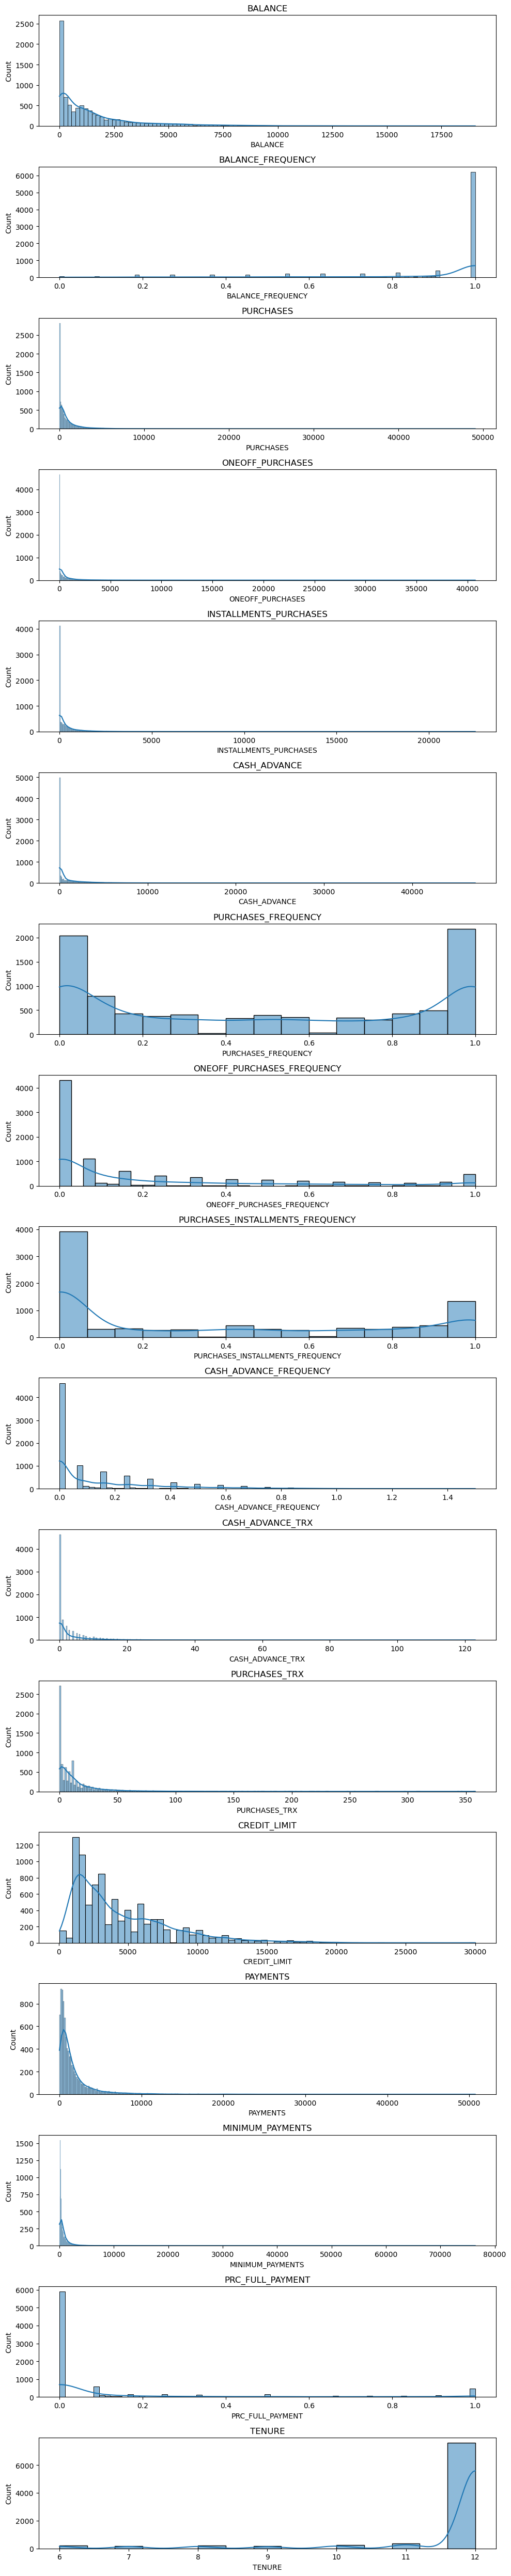

In [15]:
plt.figure(figsize=(10,50))
for i in range(len(cc_df.columns)):
  plt.subplot(17, 1, i+1)
  sns.histplot(data=cc_df[cc_df.columns[i]], kde=True)
  plt.title(cc_df.columns[i])

plt.tight_layout()

* Checking the correlations between every two columns.

<Axes: >

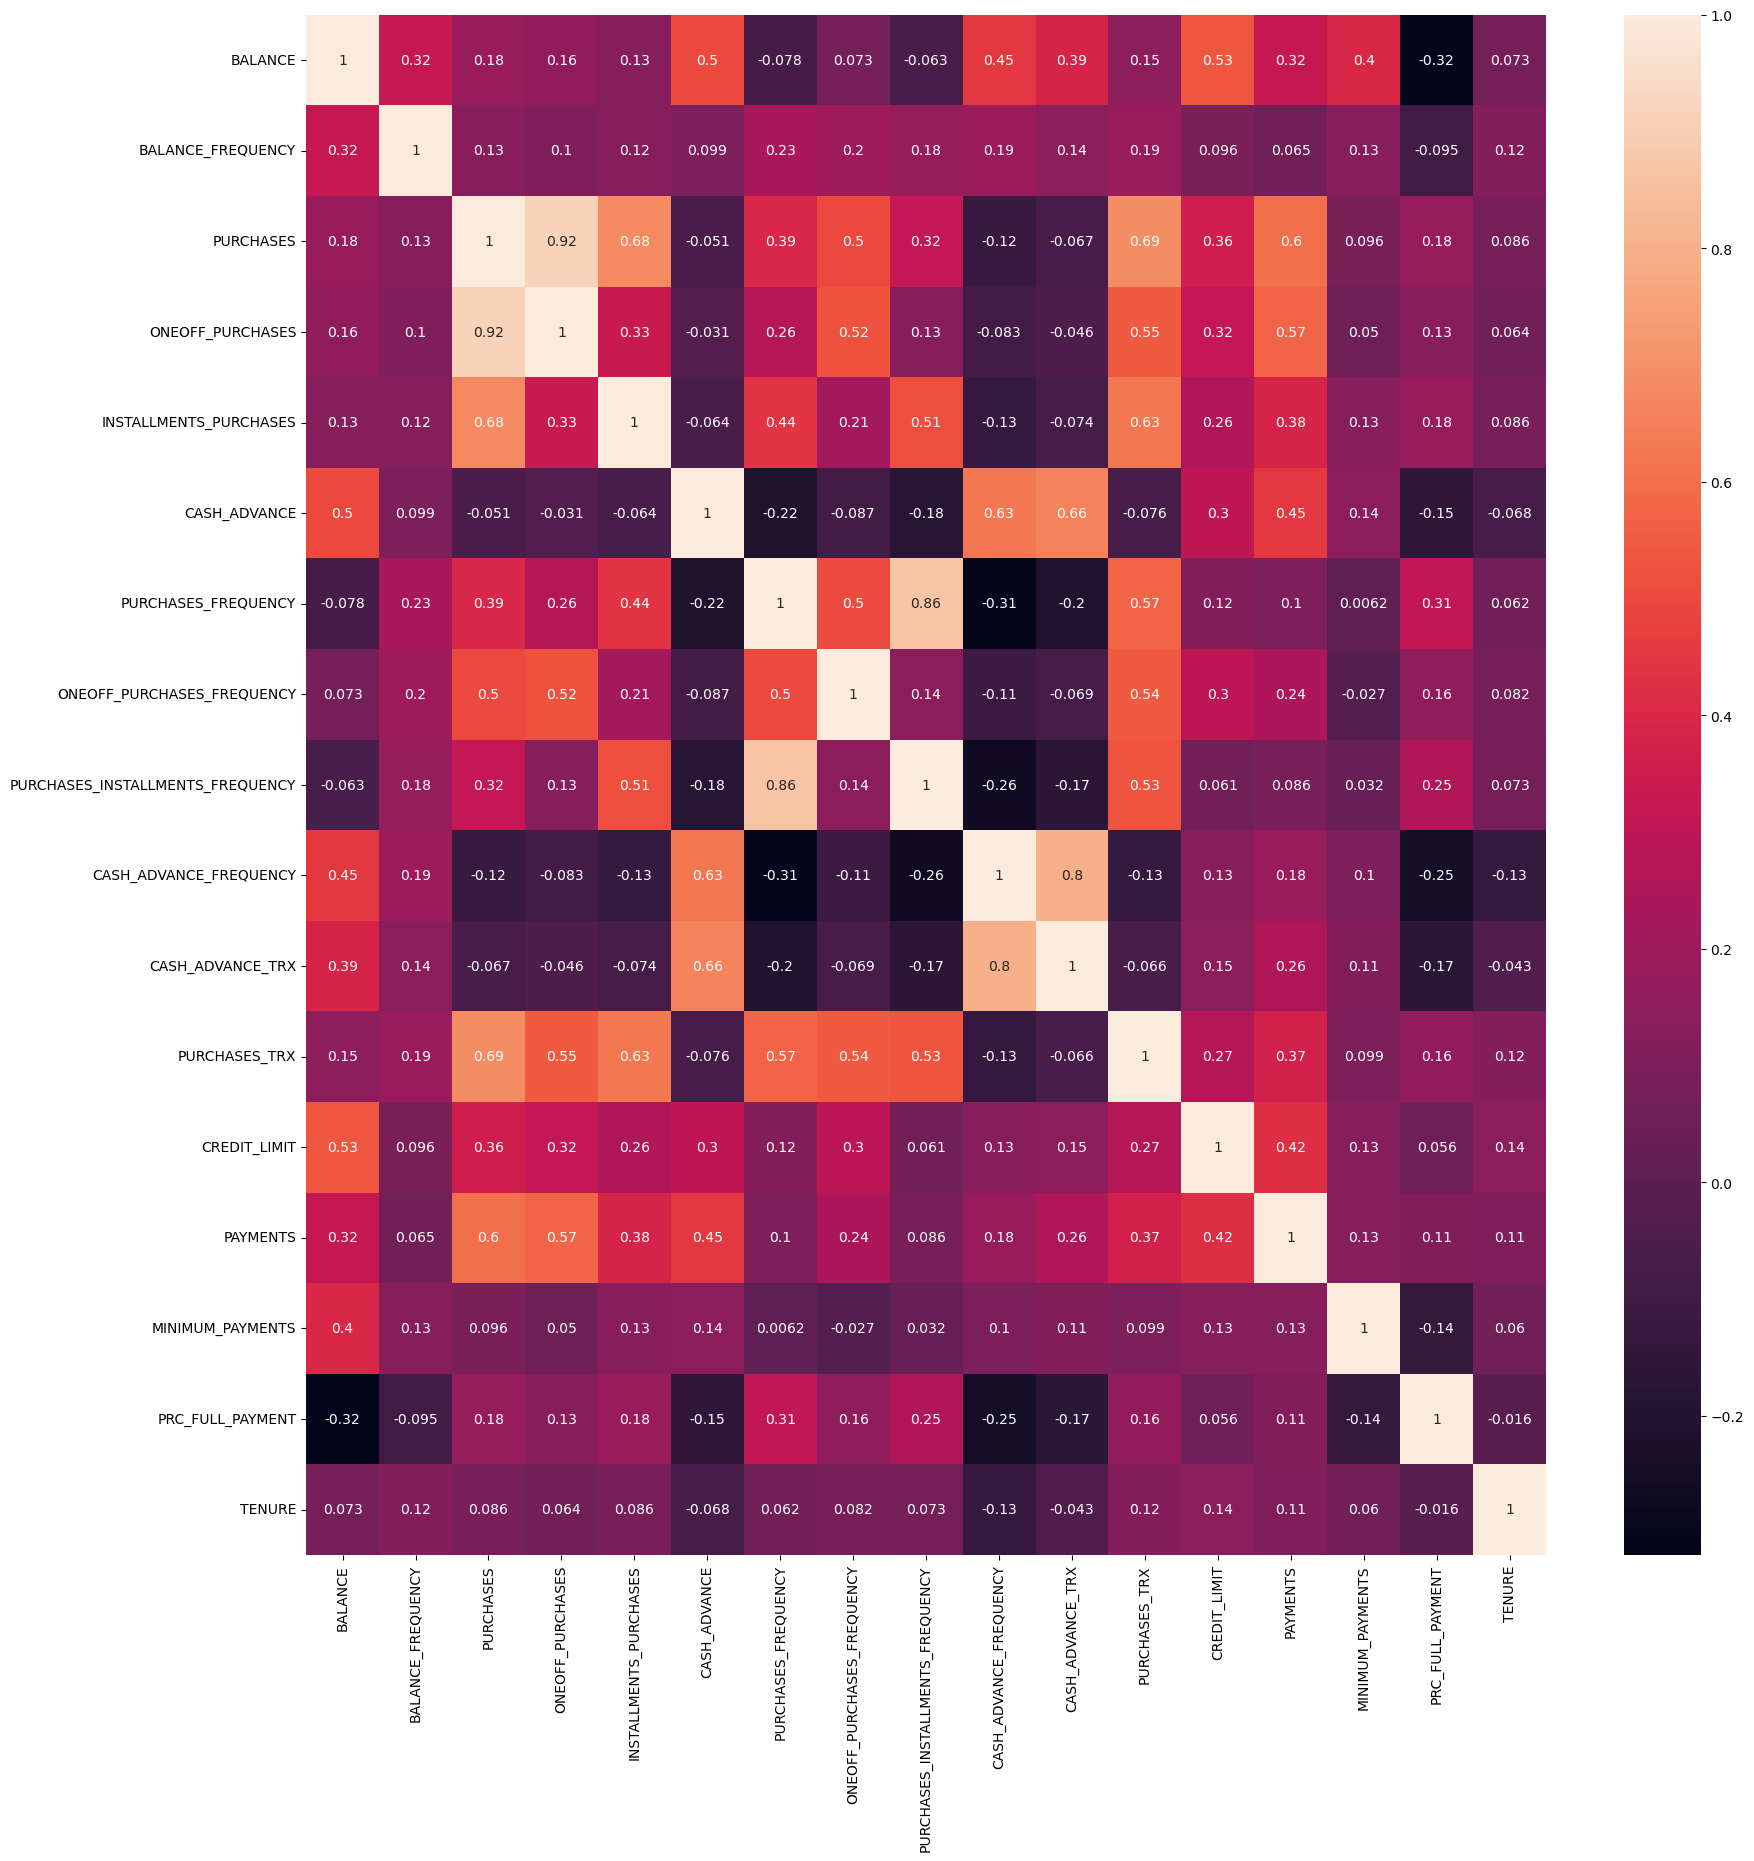

In [16]:
correlations = cc_df.corr()
f, ax = plt.subplots(figsize = (20, 20))
sns.heatmap(correlations, annot = True)

# From the results, we can see 3 pairs of strong correlation:
1. "PURCHASES" and "ONEOFF_PURCHASES" -- 0.92
2. "PURCHASES_FREQUENCY" and 'PURCHASES_INSTALLMENT_FREQUENCY' --0.86
3. "CASH_ADVANCE_TRX" and "CASH_ADVANCE_FREQUENCY" --0.8

# Step 4: Feature Transformation (using 'StandardScaler' and 'normalize').

In [17]:
# Scale the data 
scaler = StandardScaler()
cc_df_scaled = scaler.fit_transform(cc_df)

In [18]:
# Shape of new dataframe
cc_df_scaled.shape

(8950, 17)

In [19]:
cc_df_scaled

array([[-0.73198937, -0.24943448, -0.42489974, ..., -0.3024    ,
        -0.52555097,  0.36067954],
       [ 0.78696085,  0.13432467, -0.46955188, ...,  0.09749953,
         0.2342269 ,  0.36067954],
       [ 0.44713513,  0.51808382, -0.10766823, ..., -0.0932934 ,
        -0.52555097,  0.36067954],
       ...,
       [-0.7403981 , -0.18547673, -0.40196519, ..., -0.32687479,
         0.32919999, -4.12276757],
       [-0.74517423, -0.18547673, -0.46955188, ..., -0.33830497,
         0.32919999, -4.12276757],
       [-0.57257511, -0.88903307,  0.04214581, ..., -0.3243581 ,
        -0.52555097, -4.12276757]])

# Step 5: Dimensionality Reduction (PCA)

In [20]:
# Principal Component Analysis
pca = PCA(n_components=2)
principal_comp = pca.fit_transform(cc_df_scaled)

In [21]:
# Creating a new dataframe for visualization
pca_df = pd.DataFrame(data = principal_comp, columns =['pca1','pca2'])

In [22]:
pca_df.head()

,pca1,pca2
0,-1.683649,-1.072241
1,-1.134085,2.509150
2,0.969395,-0.383577
3,-0.888220,0.004648
4,-1.600021,-0.683795


# Step 6: Modeling (using K-Means Clustering to group observations with similar attribute values).

1. We'll select the optimal number of clusters according to "Elbow Method"

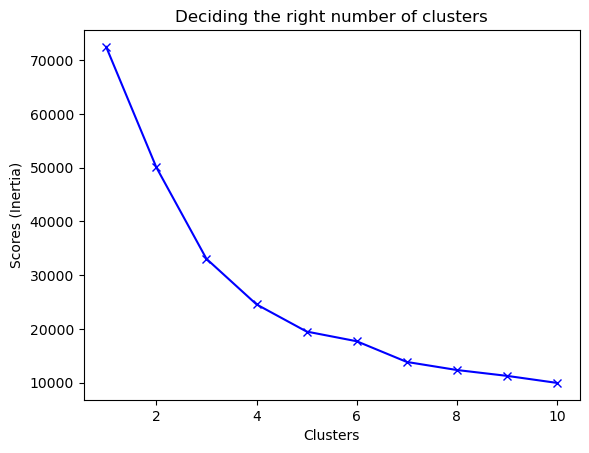

In [23]:
scores_1 = []
range_values = range(1, 11) 
for i in range_values:
  kmeans = KMeans(n_clusters = i)
  kmeans.fit(principal_comp) 
  scores_1.append(kmeans.inertia_)
  
plt.plot(range_values, scores_1, 'bx-') 
plt.title('Deciding the right number of clusters')
plt.xlabel('Clusters')
plt.ylabel('Scores (Inertia)')
plt.show()

2. Determining the optimal number of clusters using Silhouette Score.

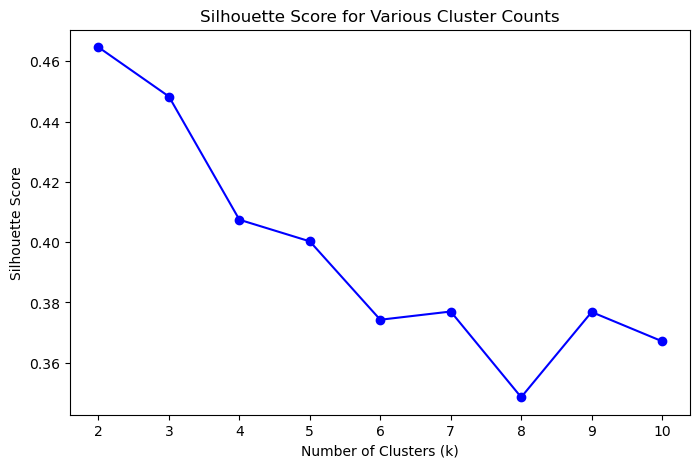

In [24]:
silhouette_scores = []

# Start from k=2. Since, Silhouette Score is not defined for k=1
range_values = range(2, 11) 

for i in range_values:
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(principal_comp)
    
    # Calculate Silhouette Score on the PCA data
    score = silhouette_score(principal_comp, kmeans.labels_)
    silhouette_scores.append(score)

# Visualize the Silhouette Scores
plt.figure(figsize=(8, 5))
plt.plot(range_values, silhouette_scores, 'bo-')
plt.title('Silhouette Score for Various Cluster Counts')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.show()

* From this plot, 4th cluster seems to be the elbow of the curve.
* Since, the values does not reduce to linearly until 8th cluster, so we may consider using 8 clusters in this case.

3. Applying K-Means Algorithm

In [25]:
kmeans = KMeans(8)
kmeans.fit(principal_comp)
labels = kmeans.labels_

In [26]:
kmeans.cluster_centers_.shape

(8, 2)

* Perform inverse transformation to see the original data

1. INVERSE TRANSFORM THE CLUSTER CENTERS

In [27]:
# PCA Inverse: Maping the 2-component centers back to the 17-feature scaled space
centers_17D_scaled = pca.inverse_transform(kmeans.cluster_centers_)

In [28]:
# Scaler Inverse: Map the 17-feature scaled space back to the original values
final_cluster_centers = scaler.inverse_transform(centers_17D_scaled)

In [29]:
# Creating final DataFrame for analysis
cluster_centers_df = pd.DataFrame(
    data = final_cluster_centers, 
    columns = [cc_df.columns])

print("Final Cluster Centers (Original Scale):")
cluster_centers_df

Final Cluster Centers (Original Scale):


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,878.827826,0.821676,-318.258518,-292.463752,-25.549662,636.114965,0.336591,0.076738,0.237100,0.122083,2.444897,0.766744,2981.035823,274.391488,452.819127,0.122358,11.361521
1,1342.387909,0.923175,3222.967406,2000.345224,1223.163498,4.219078,0.898183,0.437231,0.715222,0.008637,-0.252652,40.553098,5710.722139,3064.011951,866.782107,0.305815,11.806247
2,6017.989838,1.040098,1372.061782,1083.062264,288.854013,5884.512816,0.069302,0.164354,-0.024694,0.599331,18.525734,11.087741,9028.819851,5613.480740,2929.780327,-0.145999,11.476347
3,8899.625352,1.504465,16484.214424,10919.244179,5565.991099,4207.417857,2.367548,1.687238,1.925677,0.212817,10.204477,179.283024,21549.340169,18254.330023,5115.074082,0.571521,13.356312
4,423.156196,0.839604,1076.928451,574.380911,502.978396,-333.194347,0.627334,0.229729,0.489073,0.008415,-0.872194,17.567251,3440.643958,853.309326,320.068761,0.240834,11.549385
5,2758.386737,0.891290,-125.555611,-61.701797,-63.793186,2694.410868,0.165292,0.064510,0.078354,0.316278,8.847026,-0.337328,4918.656916,1937.267661,1334.800067,-0.001864,11.348976
6,3599.549606,1.082918,6609.009854,4296.362684,2313.275496,1447.083144,1.237705,0.750775,0.991656,0.096164,3.574190,75.398064,10070.872636,7209.523320,2103.325795,0.349953,12.195540
7,2777.723951,0.942032,1948.986719,1267.067951,682.180210,2039.581057,0.521745,0.280028,0.383582,0.222564,6.375940,23.415224,6274.425733,3365.962175,1460.406488,0.123865,11.614506


* Cluster 6 (The Ultra-VIP / Top Tier): This is your highest value segment for both high volume and good repayment. Features the highest metrics across the board: highest Purchases ($\sim\$16.4\text{K}$), highest Credit Limit ($\sim\$21.5\text{K}$), and the highest percentage of full payments ($\sim57\%$). These customers are a target for retention and exclusive services.

* Cluster 4 (Aggressive Debt Revolvers): This is the highest-risk, high-interest revenue segment. Characterized by highest Balance ($\sim\$6.0\text{K}$) and highest Cash Advance ($\sim\$5.8\text{K}$), while having the lowest (near zero/negative) percentage of full payment. Strategy must balance high-interest revenue with risk mitigation.

* Cluster 2 (Premium High Spenders): This segment represents excellent, high-volume customers. Features very high Purchases ($\sim\$6.7\text{K}$) and a high Credit Limit ($\sim\$10.1\text{K}$), with a solid percentage of full payment ($\sim35\%$). A target for increasing spending habits and credit limit increases.

* Cluster 5 (Frequent Transactors): These are low-risk, highly engaged customers. Defined by the highest Purchase Frequency ($\sim0.9$ transactions per period) and low cash advance usage. They use the card constantly for purchases and pay off debt regularly (30% full payment rate).

* Cluster 1 (Pure Cash Users / High-Debt Risk): A very specific, high-interest segment that uses the card almost exclusively for cash advances ($\sim\$2.7\text{K}$) and virtually no purchases. They carry a high balance and have a near-zero percentage of full payment.

* Cluster 7 (Mid-Tier Revolvers): A large, standard revolving segment. Features high Balance ($\sim\$2.7\text{K}$) and a mixture of moderate purchases and high cash advance ($\sim\$2.0\text{K}$). They rarely pay in full (12% full payment rate).

* Cluster 0 (Low-Debt Installment Users): These are careful customers who use the card for moderate purchases ($\sim\$1.1\text{K}$) and installments. They have the lowest average Balance ($\sim\$430$) and low credit limit, suggesting they are financially conservative.

* Cluster 3 (Conservative / Low Engagement): These are the least active customers. Defined by low engagement metrics, very low purchases, and the lowest Payments ($\sim\$266$). They represent the lowest immediate value but are a potential target for activation campaigns.

2. ASSIGN CLUSTER LABELS TO ORIGINAL DATAFRAME

In [35]:

cc_df_cluster = pd.concat([cc_df.reset_index(drop=True), pd.DataFrame({'CLUSTER':labels})], axis = 1)

In [36]:
cc_df_cluster.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,CLUSTER
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,0
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,5
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,4
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12,0
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,0


In [37]:
cc_df_cluster.shape

(8950, 18)

# Step 7: Visualization and Interpretation.

1. Visualization I: Plotting Feature Histograms (Cluster Profiling)

* Visually confirm which clusters have high/low values for key metrics like BALANCE, PURCHASES, and CREDIT_LIMIT.

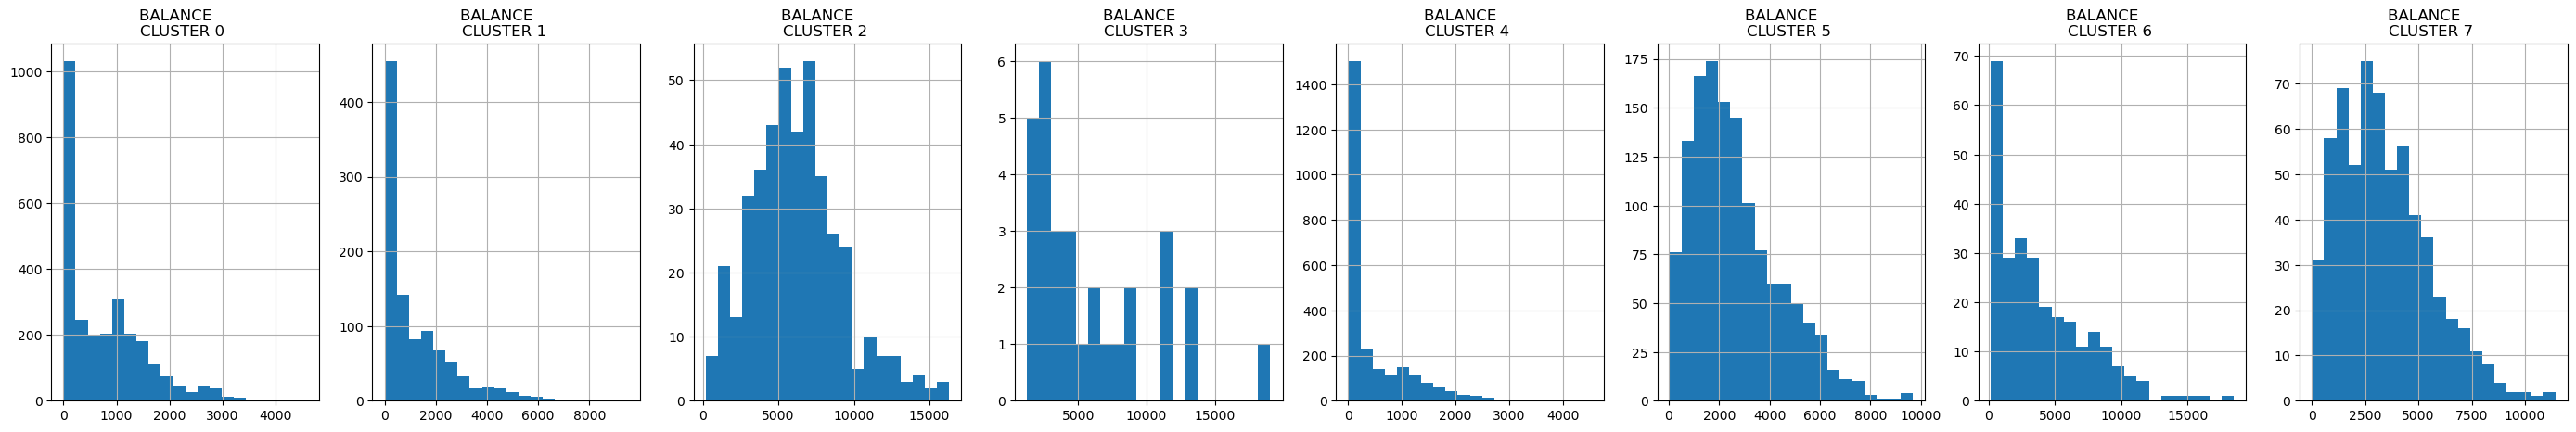

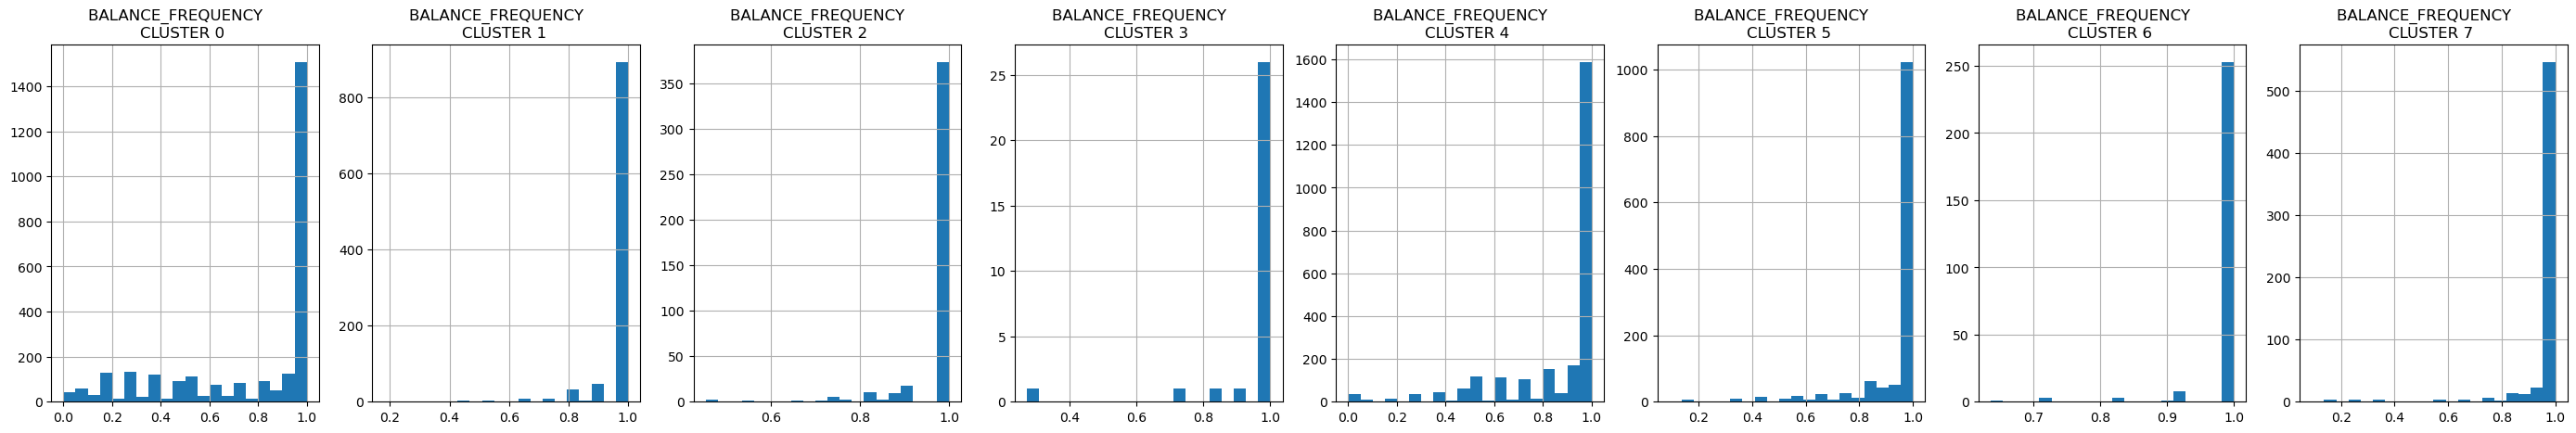

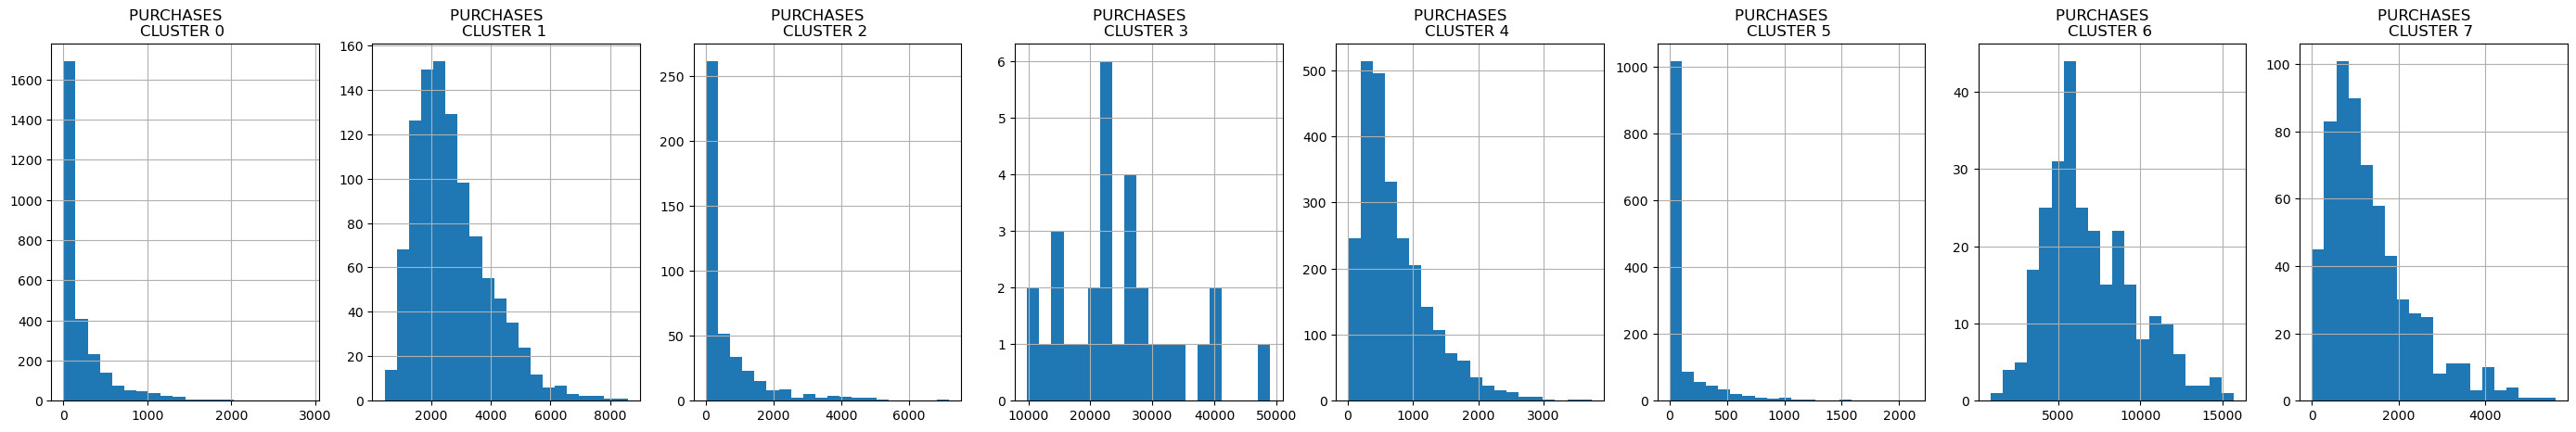

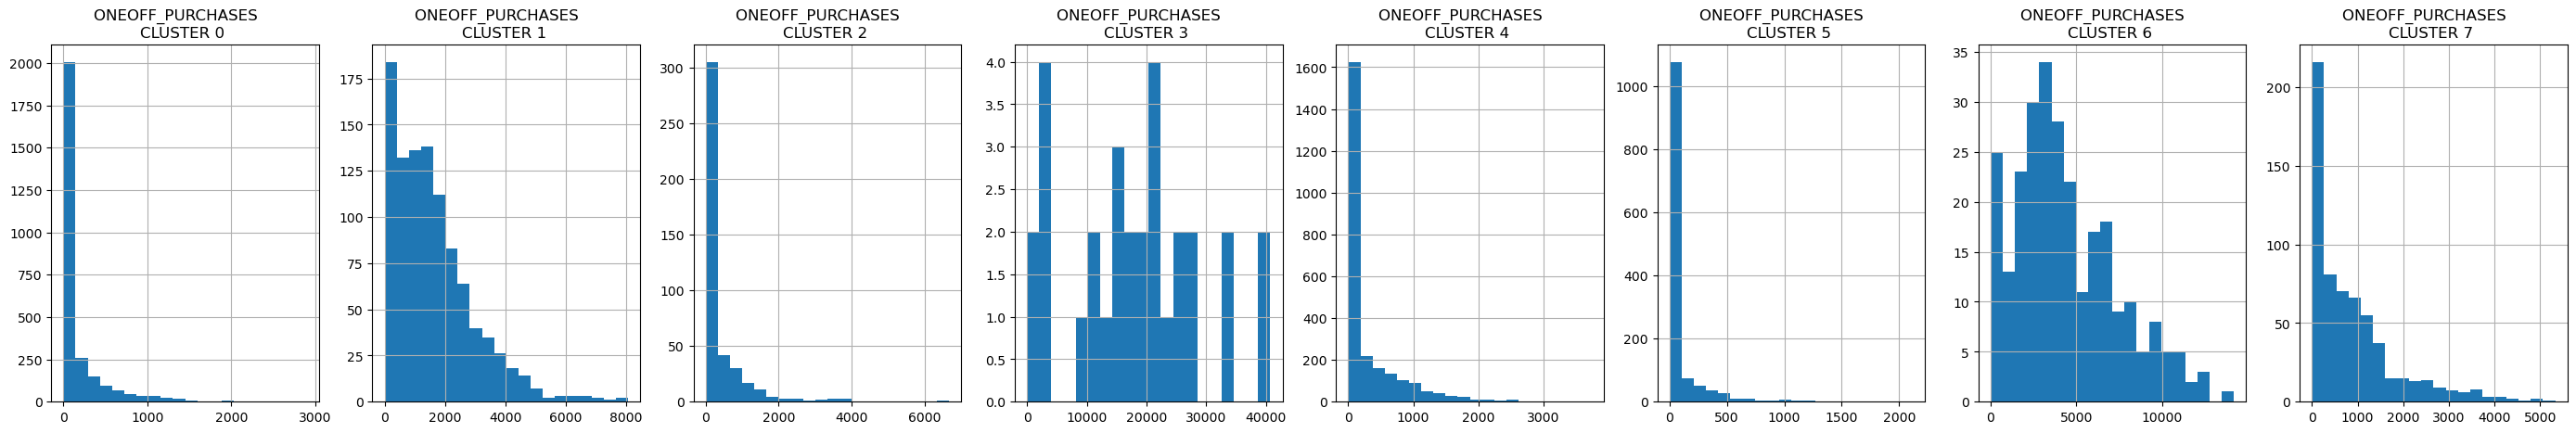

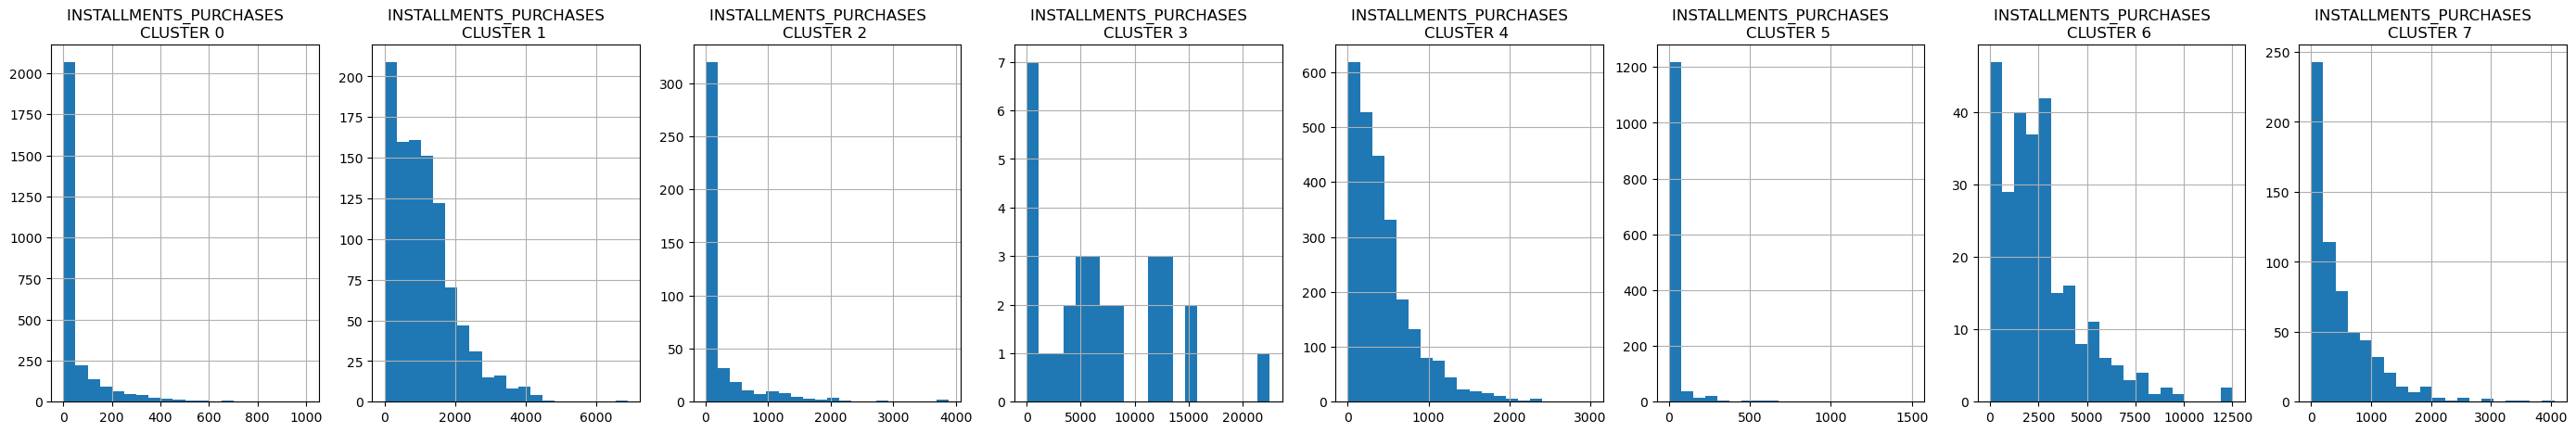

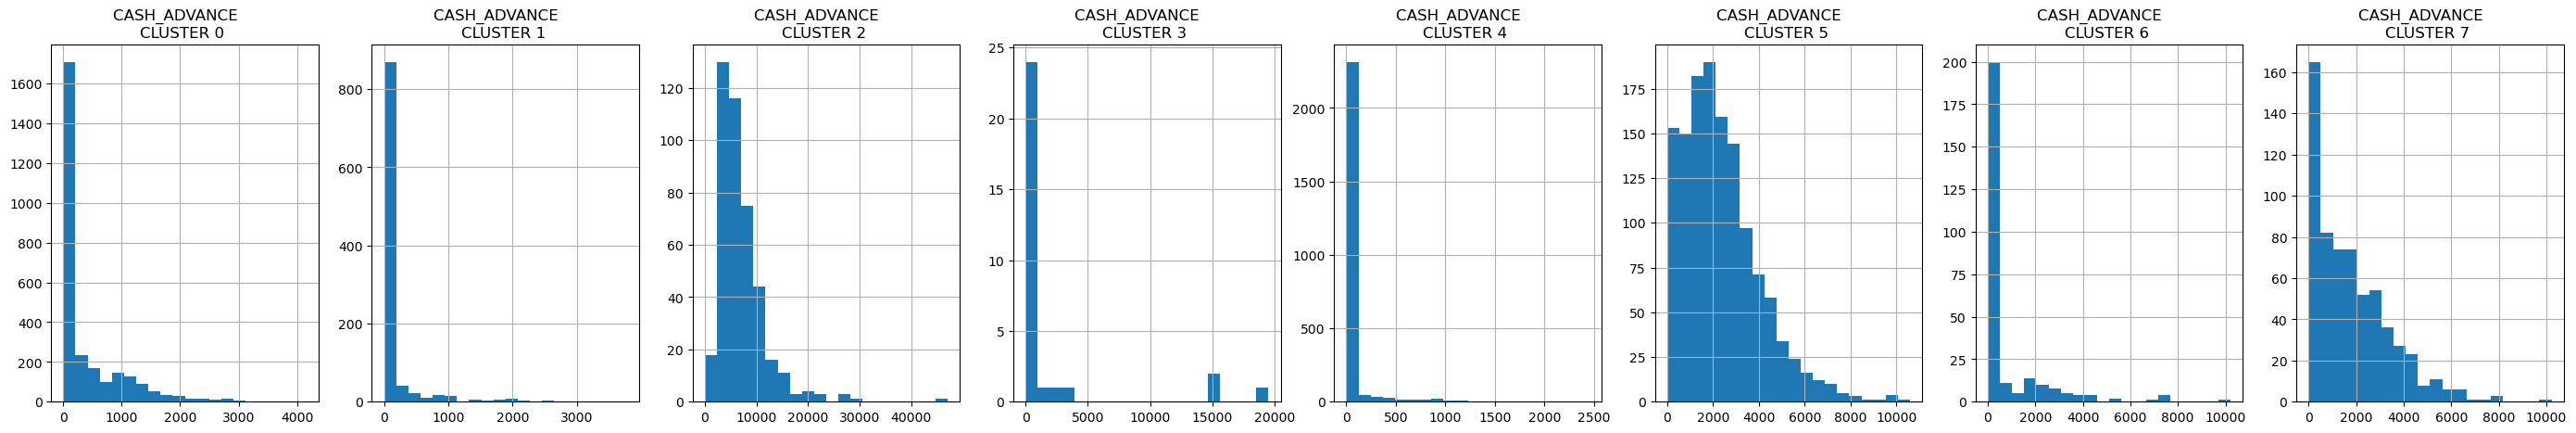

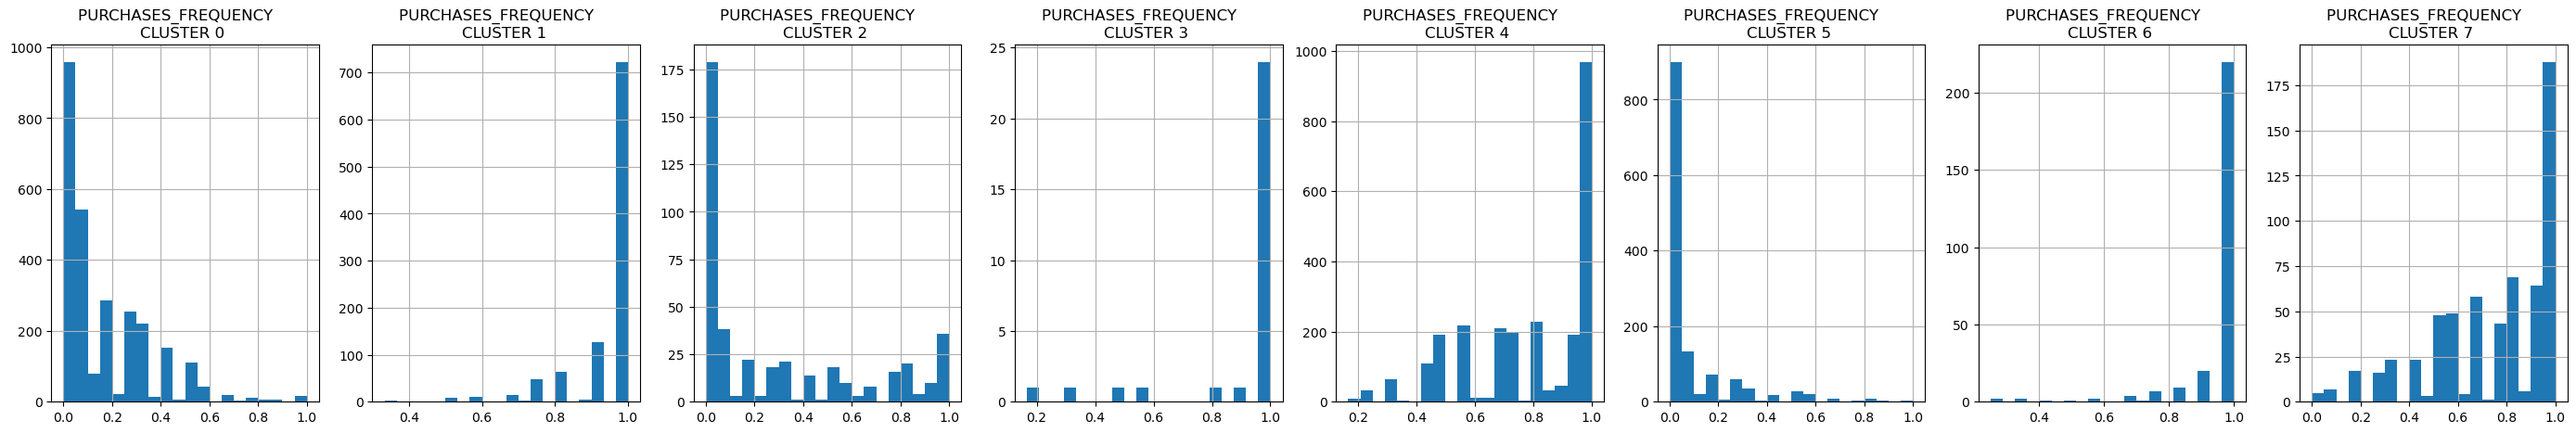

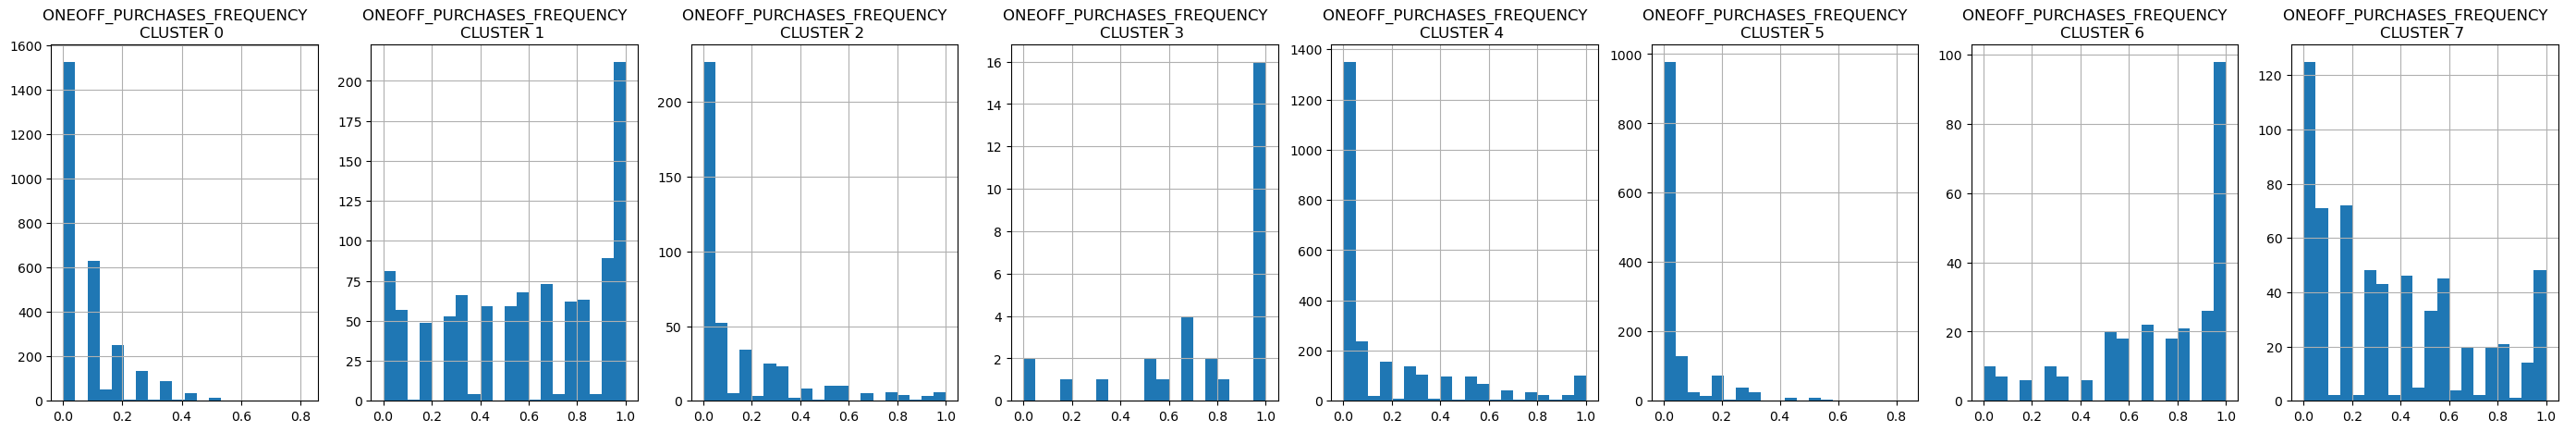

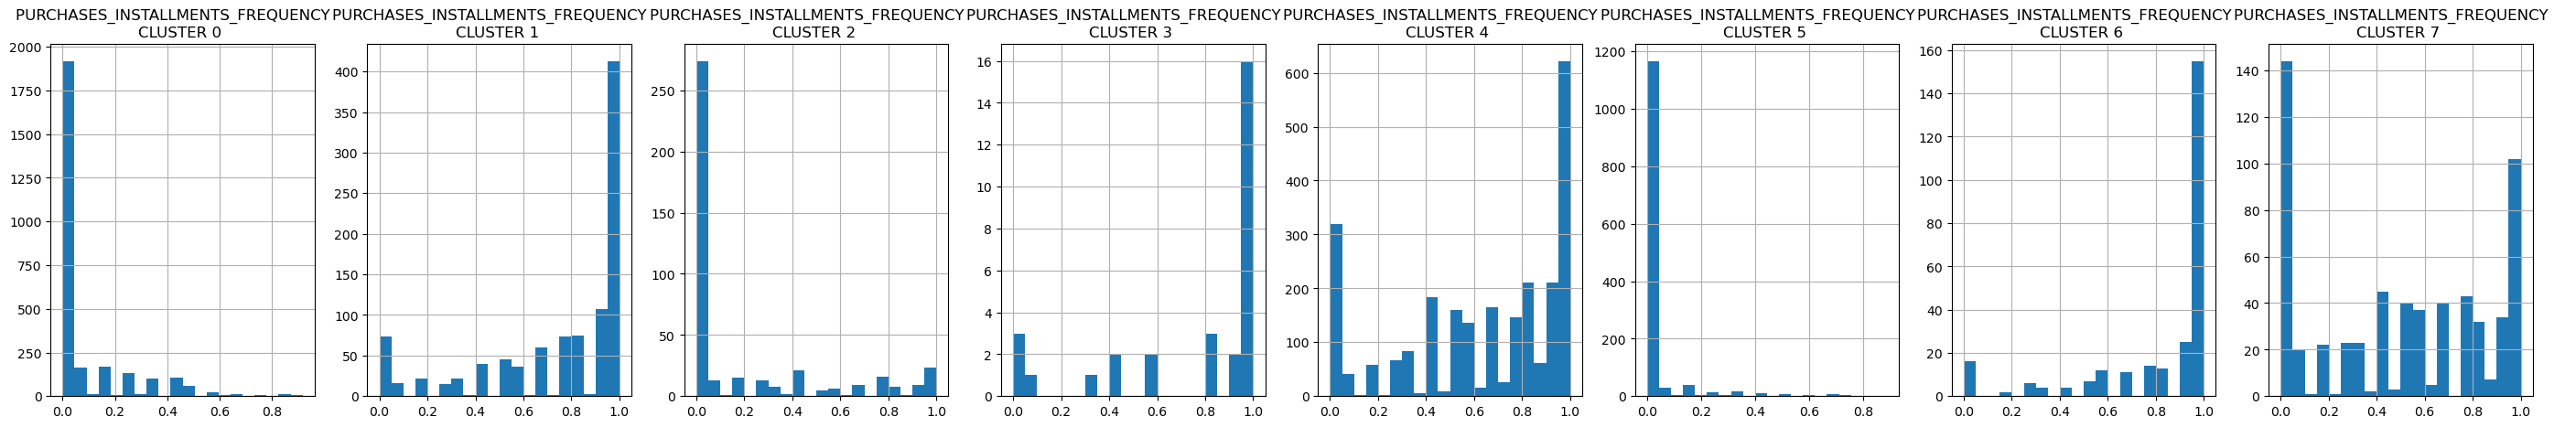

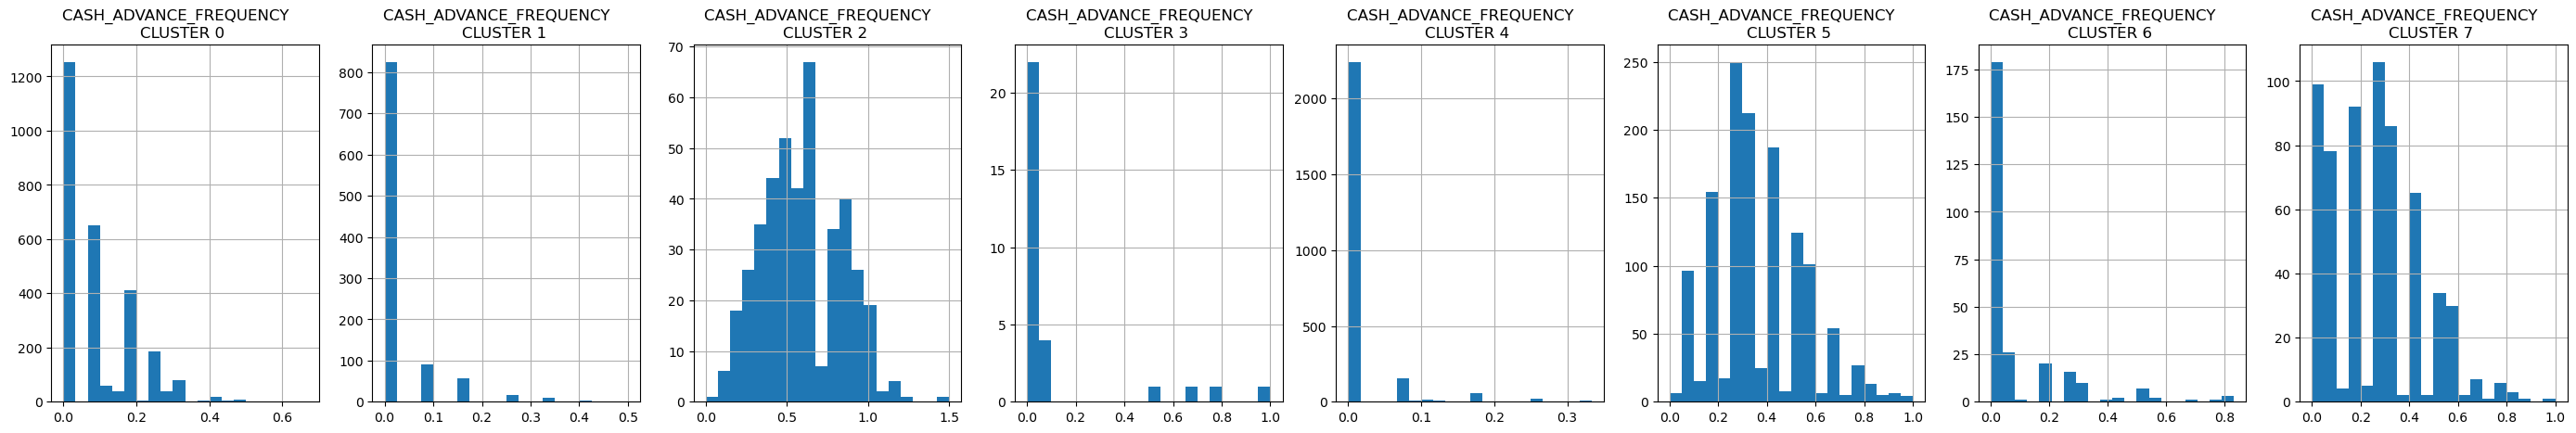

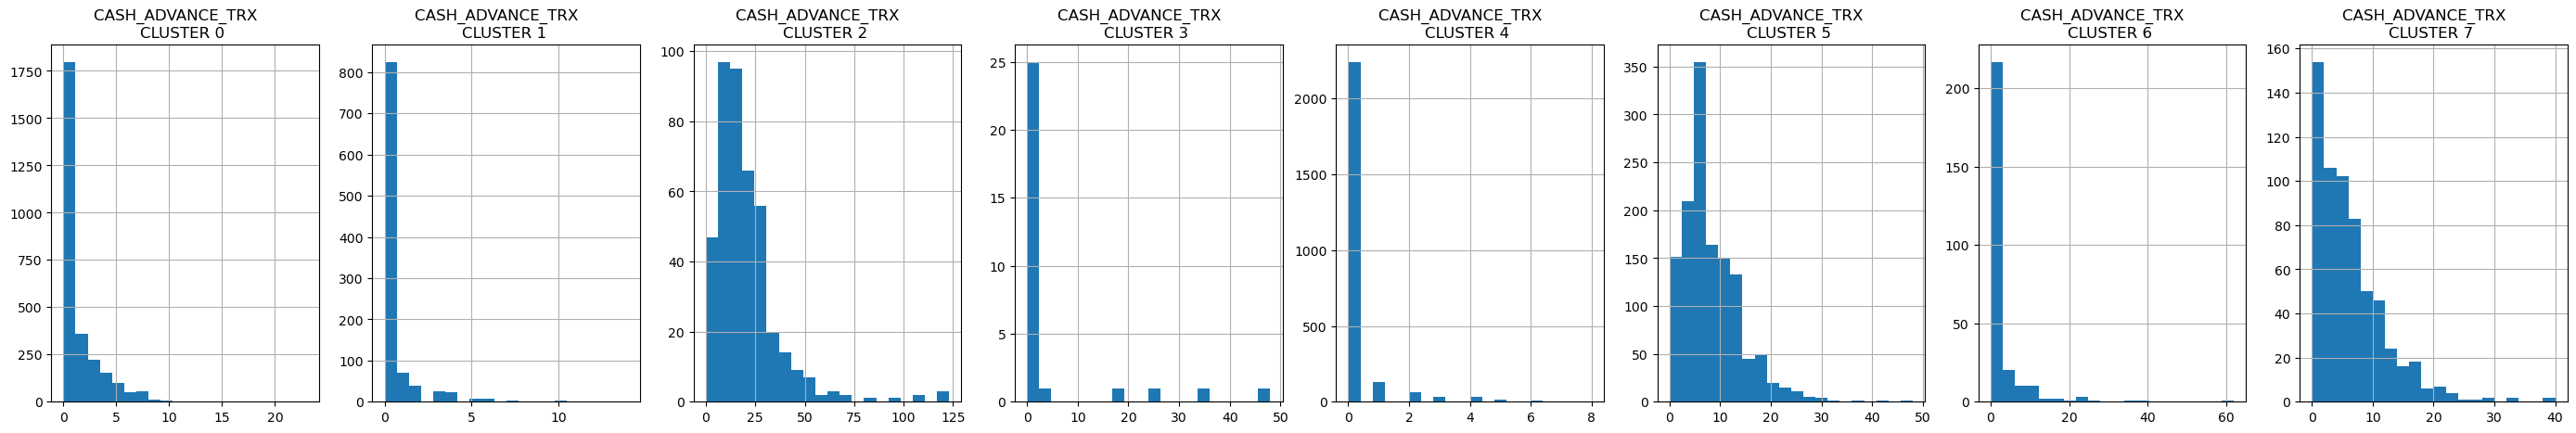

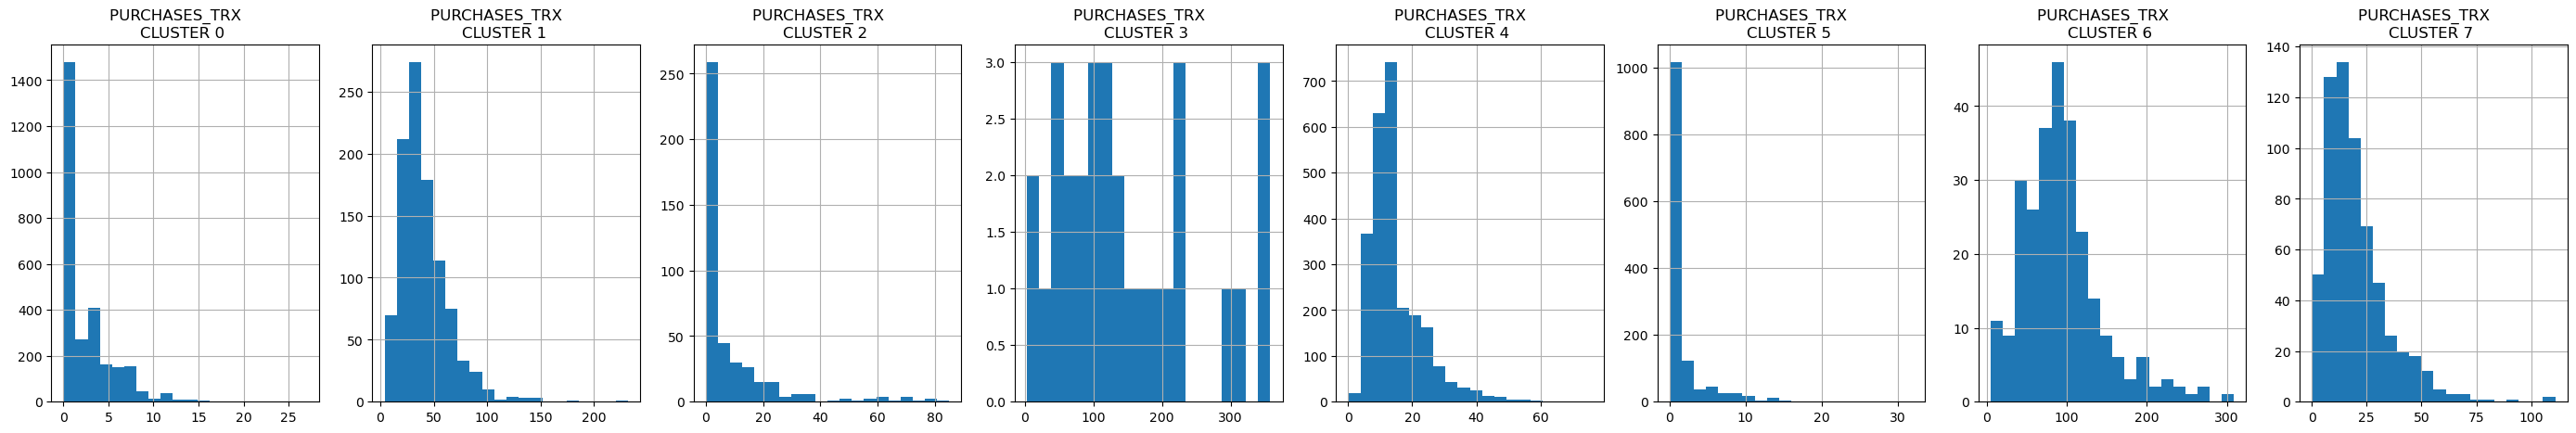

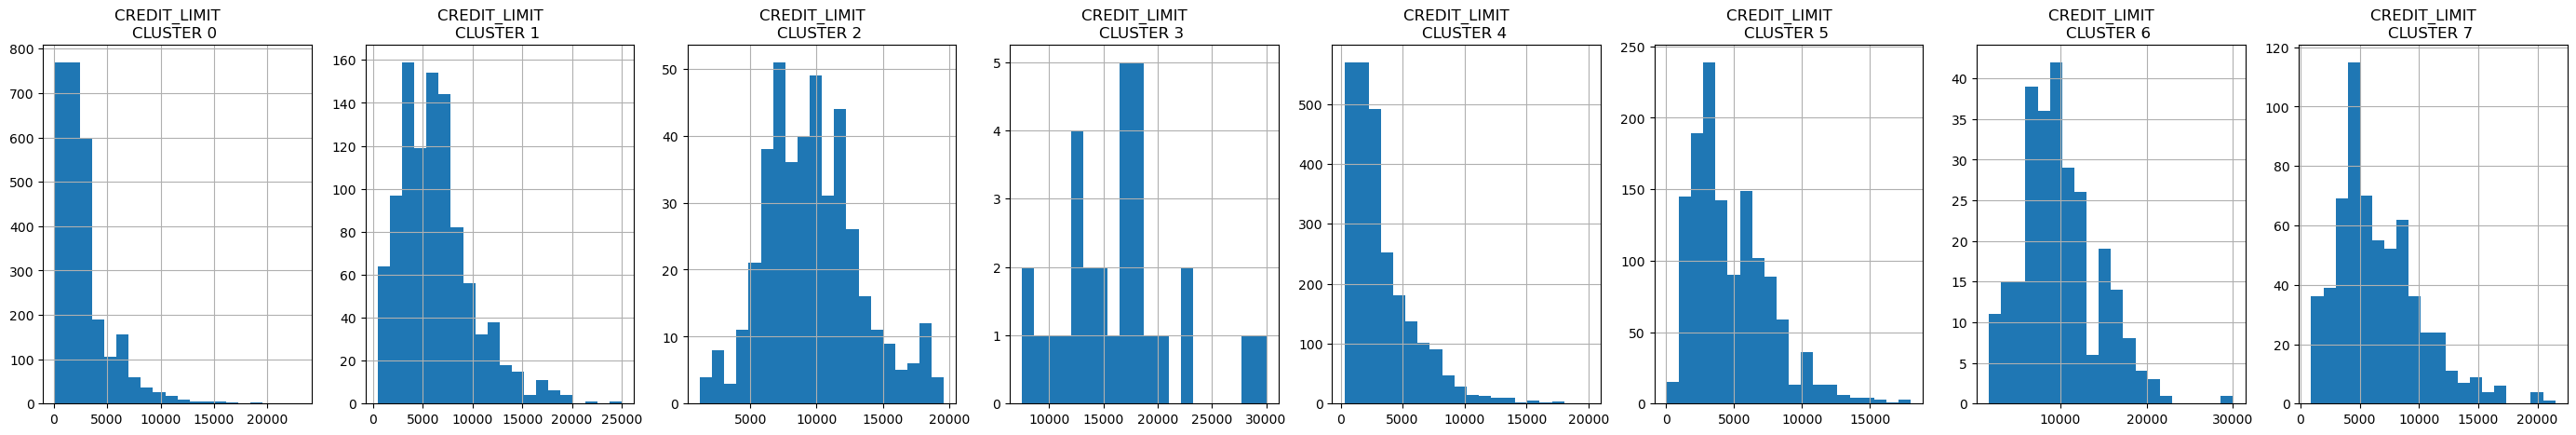

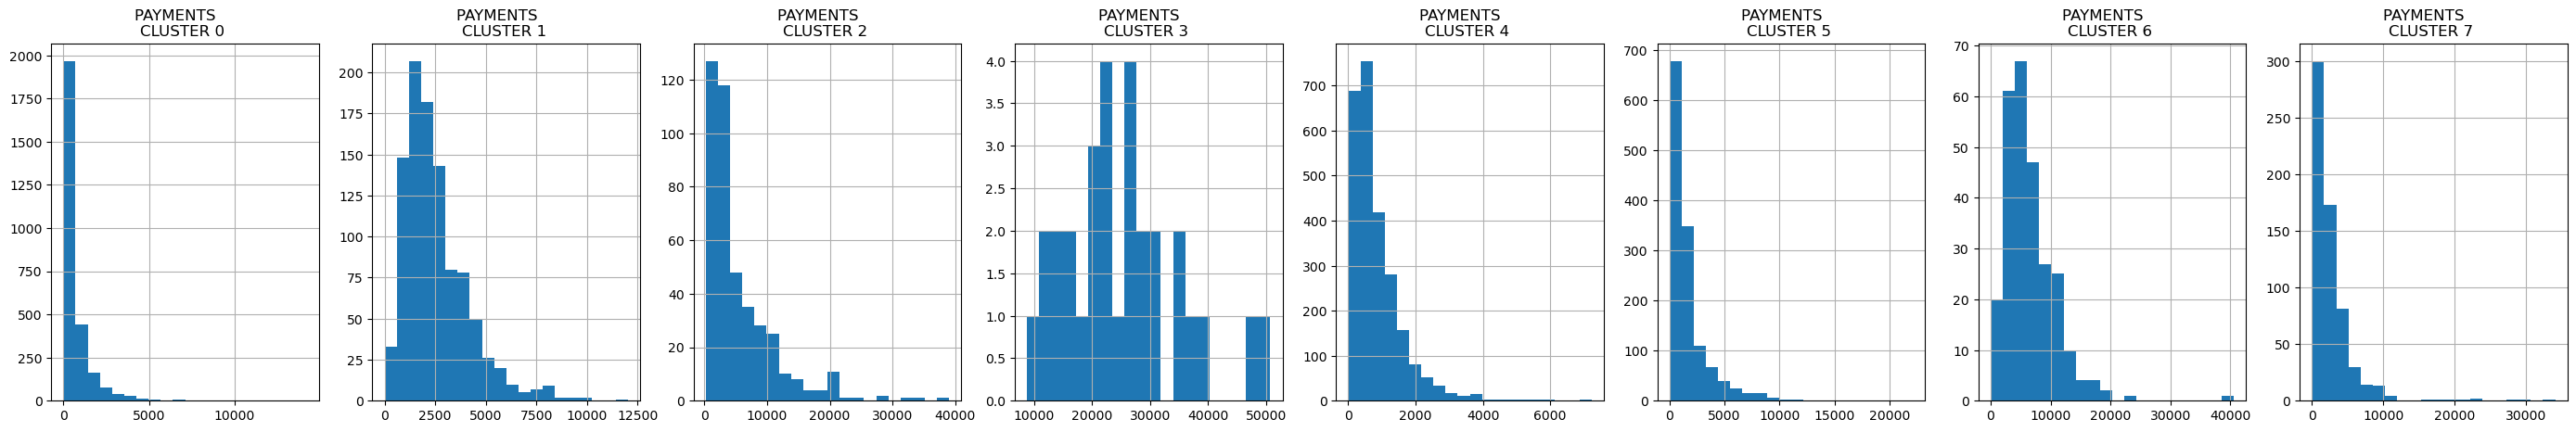

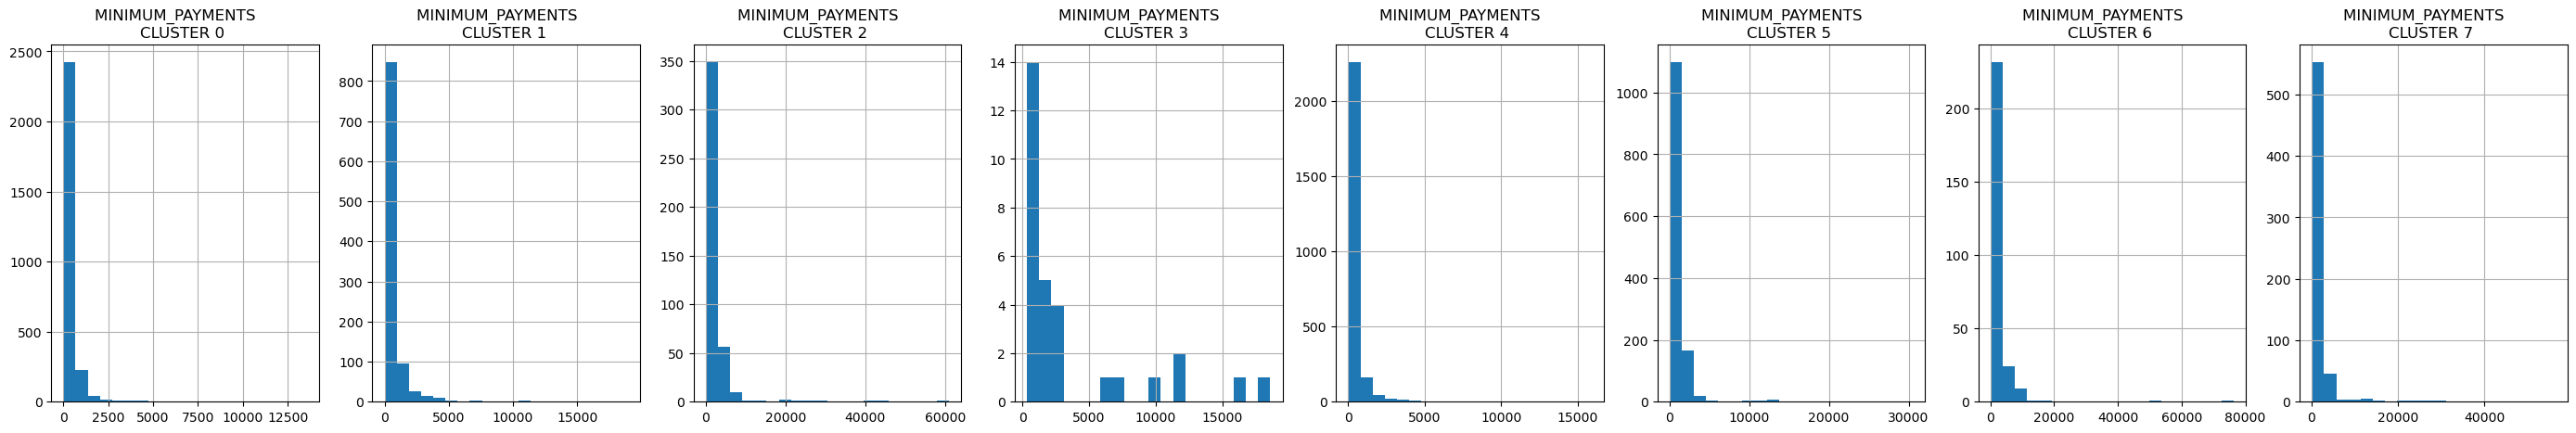

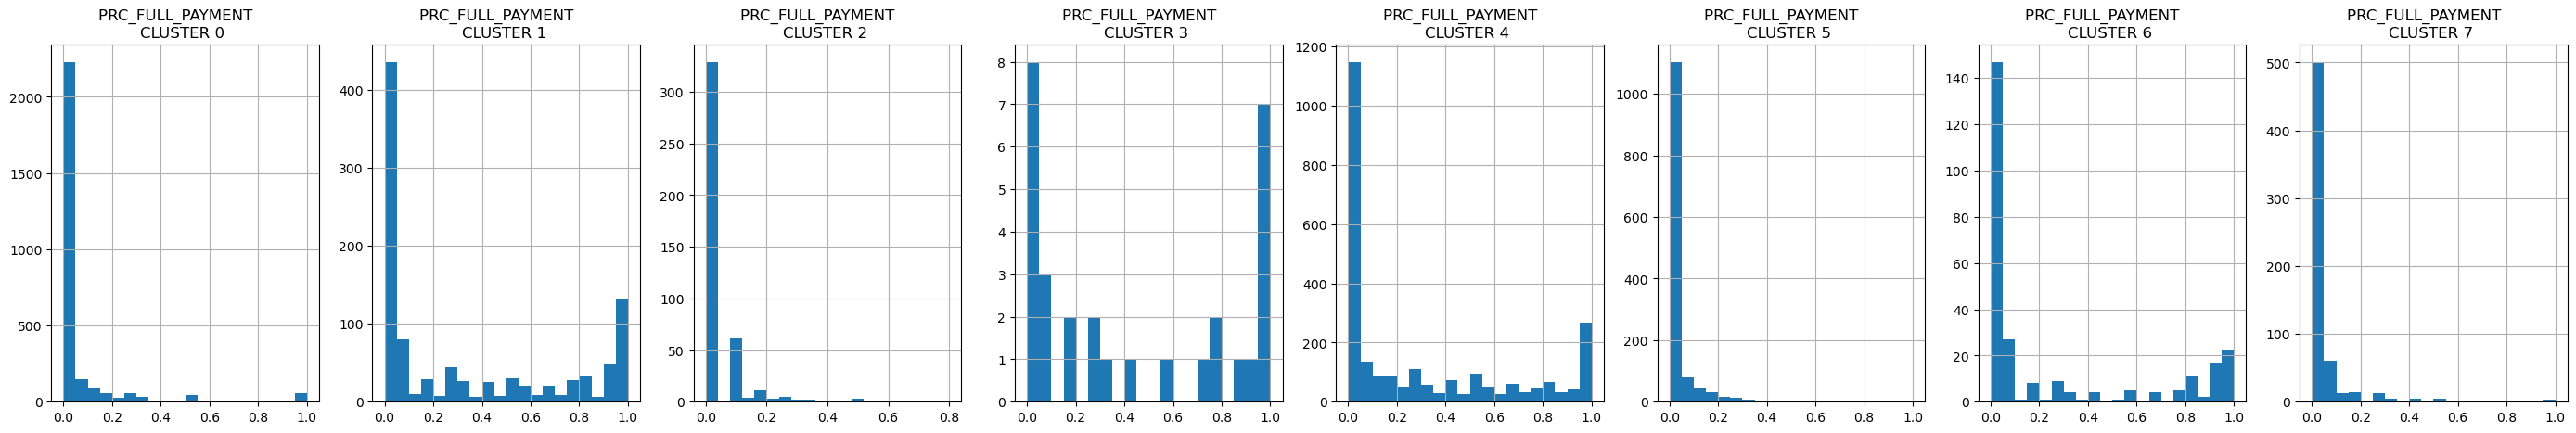

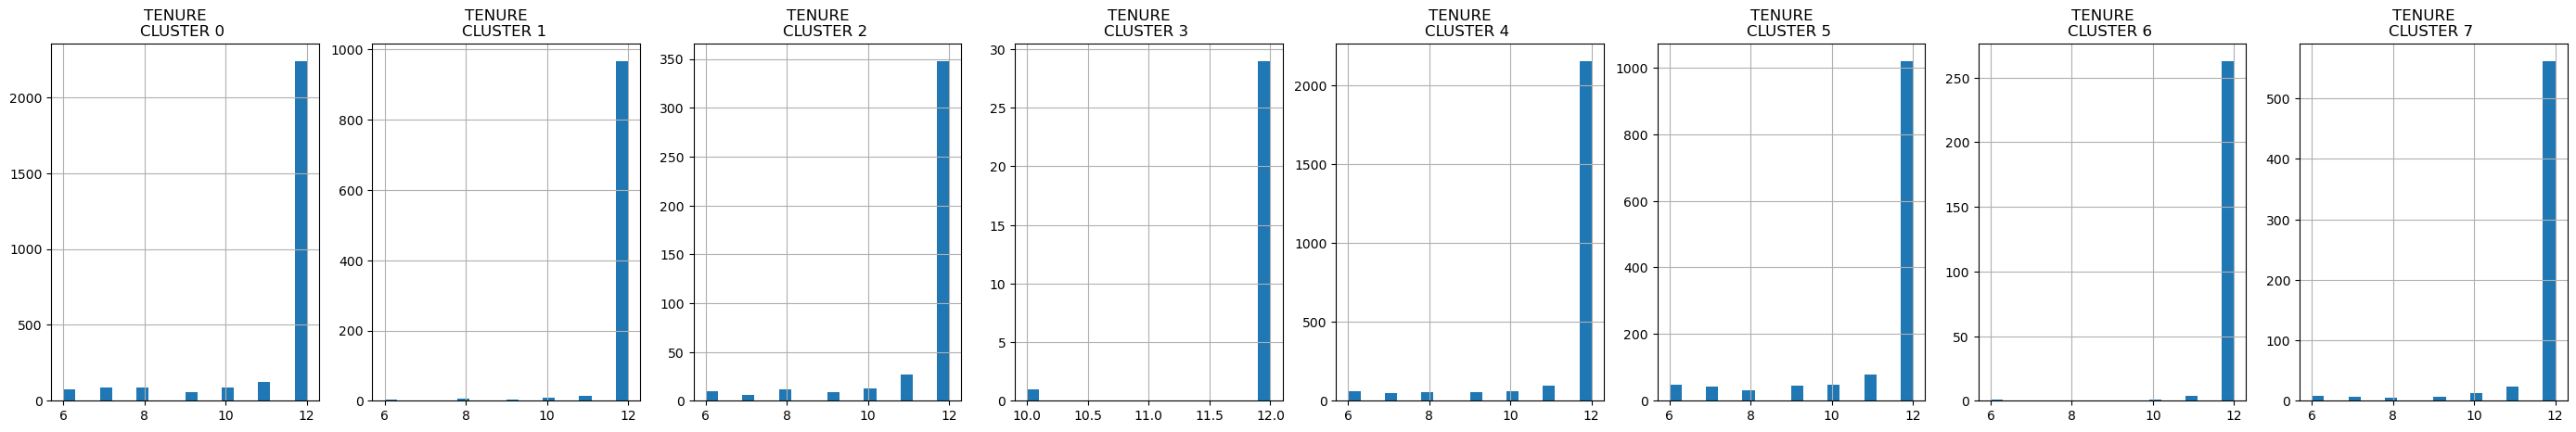

In [31]:
for i in cc_df.columns:
  plt.figure(figsize = (35, 5))
  for j in range(8):
    plt.subplot(1,8,j+1)
    cluster = cc_df_cluster[cc_df_cluster['CLUSTER'] == j]
    cluster[i].hist(bins = 20)
    plt.title('{}    \nCLUSTER {} '.format(i,j))
  
  plt.show()

2. Visualization II: PCA Scatter Plot (Model Separation)

* Show the visual separation of the 8 clusters.

In [32]:
# 1. Preparing data for plotting the scatter plot graph by adding the labels to the PCA DataFrame
# Createing the Cluster Mapping Dictionary
cluster_name_map = {
    0: "Low-Debt Installment Users",
    1: "Pure Cash Users / High-Debt Risk",
    2: "Premium High Spenders",
    3: "Conservative / Low Engagement",
    4: "Aggressive Debt Revolvers",
    5: "Frequent Transactors",
    6: "Ultra-VIP / Top Tier",
    7: "Mid-Tier Revolvers"
}

pca_df_labeled = pd.concat([pca_df.reset_index(drop=True),pd.DataFrame({'CLUSTER_ID': labels})],axis=1)

# Adding the descriptive business name column
pca_df_labeled['Segment Name'] = pca_df_labeled['CLUSTER_ID'].map(cluster_name_map)

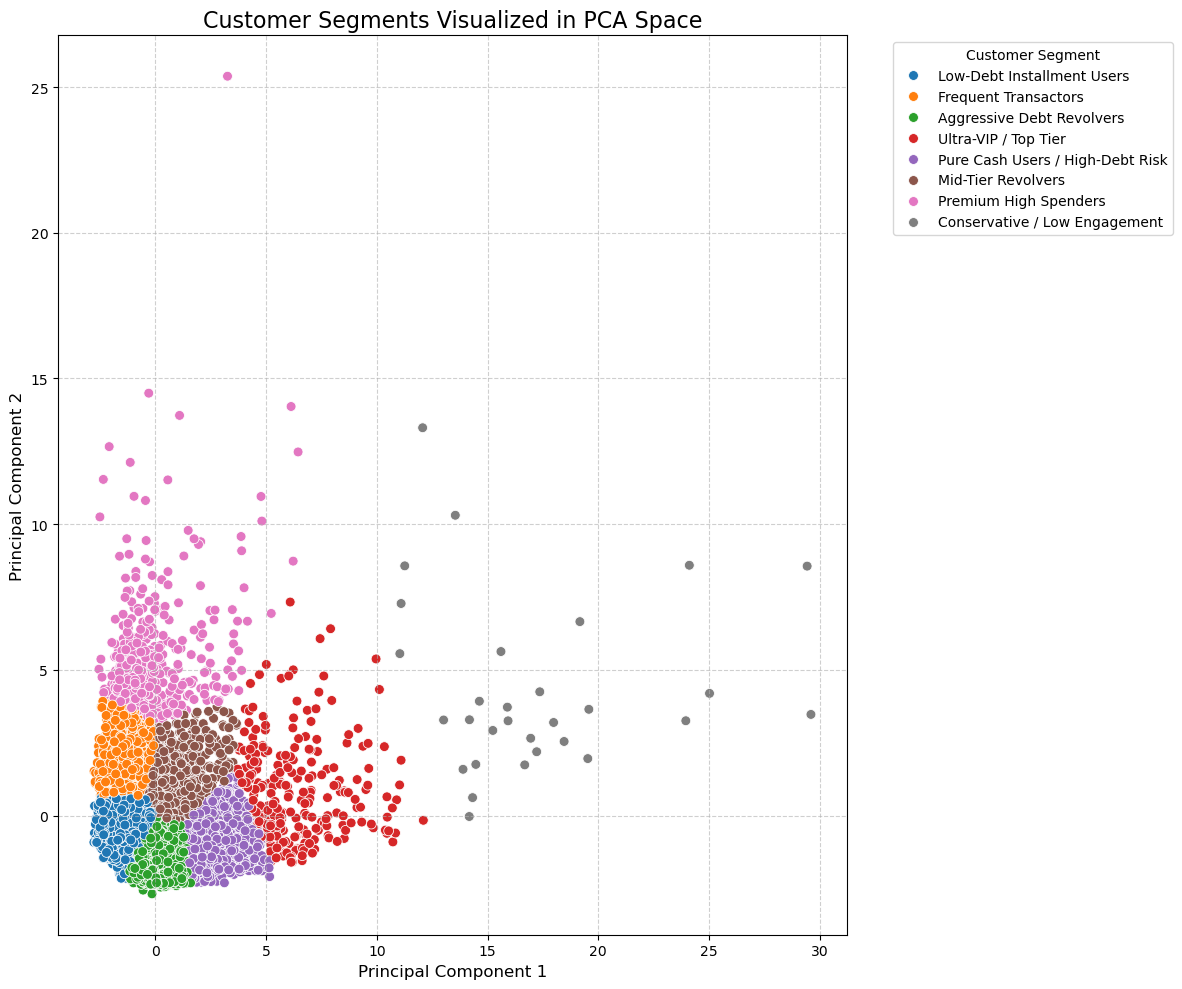

In [33]:
# 2. scatter plot

plt.figure(figsize=(12, 10))
sns.scatterplot(x="pca1", 
                y="pca2",
                # Use the new descriptive column for the legend/color
                hue="Segment Name", 
                data=pca_df_labeled, 
                palette='tab10', 
                s=50 # Set marker size
               )

plt.title('Customer Segments Visualized in PCA Space', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend(title='Customer Segment', bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#  * Final Strategic Recommendations: Actionable Customer Cohorts

This table translates the eight statistical clusters into distinct business segments and proposes tailored marketing and risk strategies for each.

| Segment Name | Key Financial Characteristic | Business Goal | Recommended Strategy |
| :--- | :--- | :--- | :--- |
| **Ultra-VIP / Top Tier** | Highest Spend, High Credit Limit, Highest Full Payment Rate | **Retention & Maximize Value** | Offer exclusive perks, personalized banking services, or concierge travel rewards to maintain loyalty. |
| **Aggressive Debt Revolvers** | Highest Balance, Highest Cash Advance, Near 0% Full Payment | **Risk Mitigation & Debt Management** | Target with balance transfer offers and structured debt relief programs to reduce default risk and ensure partial recovery. |
| **Premium High Spenders** | High Credit Limit, Very High Purchases, Moderate Full Payment Rate | **Increase Wallet Share** | Offer interest-free financing options for large purchases (e.g., 0% APR on 6-month installment plans). |
| **Frequent Transactors** | High Purchase Frequency, High Installments, Low Debt | **Encourage Loyalty & Upsell** | Introduce points multiplier rewards on everyday purchases; offer secured credit line increases to grow engagement slowly. |
| **Pure Cash Users / High-Debt Risk** | Almost Exclusively Cash Advance, High Balance, Very Low Full Payment | **High-Interest Revenue Management** | Monitor closely for default signals. If stable, offer slightly lower cash advance fees to retain high-interest revenue. |
| **Mid-Tier Revolvers** | Moderate Balance, Mix of Purchases/Cash, Low Full Payment Rate | **Balance Management & Conversion** | Focus on increasing the minimum payment compliance through timely reminders and digital incentives. |
| **Low-Debt Installment Users** | Lowest Balance, Moderate Installment Purchases | **Graduate to Transactor Status** | Offer small, low-risk credit line increases or personalized coupons for installment partners (e.g., electronics stores). |
| **Conservative / Low Engagement** | Lowest Activity Across the Board | **Activation & Re-engagement** | Target with "Welcome Back" offers, small sign-up bonuses for first purchase, or educational content on credit score benefits. |
```

In [38]:
cc_df_cluster = cc_df_cluster.reset_index(drop=True)

In [39]:
raw_data = pd.read_csv('credit_card_dataset.csv')

In [40]:
customer_ids = raw_data['CUST_ID'].reset_index(drop=True)

In [41]:
cc_segment = pd.concat([customer_ids, cc_df_cluster], axis=1)

In [42]:
cc_segment.to_csv('cc_segment.csv', index=False)

In [43]:
pca_df_labeled.head()

,pca1,pca2,CLUSTER_ID,Segment Name
0,-1.683649,-1.072241,0,Low-Debt Installment Users
1,-1.134085,2.509150,5,Frequent Transactors
2,0.969395,-0.383577,4,Aggressive Debt Revolvers
3,-0.888220,0.004648,0,Low-Debt Installment Users
4,-1.600021,-0.683795,0,Low-Debt Installment Users


In [53]:
#converting cluster_name_map to dataframe
segments = pd.DataFrame(list(cluster_name_map.items()), columns=['CLUSTER_ID', 'Segment Name'])

In [54]:
segments

,CLUSTER_ID,Segment Name
0,0,Low-Debt Installment Users
1,1,Pure Cash Users / High-Debt Risk
2,2,Premium High Spenders
3,3,Conservative / Low Engagement
4,4,Aggressive Debt Revolvers
5,5,Frequent Transactors
6,6,Ultra-VIP / Top Tier
7,7,Mid-Tier Revolvers


In [55]:
segments.to_csv('segments.csv', index=False)